# Projet Machine Learning

### Groupe 3

**Membres :**
- PONCHON Léo
- MOUFOK Sabrina
- HUANG Lei
- ZHANG Yaqi
- AYDEMIR Yagmur

In [3]:
# Librairies
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import chi2, SelectKBest

import plotly.graph_objs as go #graphiques avancés plotly
import plotly.offline as py #mode offline plotly
import plotly.express as px #visualisation rapide
import plotly.io as pio #sauvegarde d'image

# Librairies NLTK
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer #lemmatisation

from nltk import sent_tokenize #decoupage en phrases
from nltk import word_tokenize #decoupage en mots
from nltk import pos_tag #etiquetage grammatical
from nltk.stem.snowball import SnowballStemmer # Stemmatisation
from nltk.corpus import stopwords #stopwords

# Téléchargement des ressources NLTK
nltk.download('stopwords', quiet=True) #stopwords
nltk.download('wordnet', quiet=True) #WordNet
nltk.download('omw-1.4', quiet=True)


nltk.download("punkt") #tokenisation
nltk.download("punkt_tab") #tokenisation
nltk.download("averaged_perceptron_tagger") # Tags
nltk.download("averaged_perceptron_tagger_eng") # Tags anglais
nltk.download("tagsets_json") #Liste de tags
nltk.download("tagsets") #Ancienne liste


# NLP avec SpaCy
import spacy #NLP avancé
from spacy import displacy #visualisation
from spacy.lang.fr import French #modele français

#import contractions
from collections import Counter # Comptage d'occurrences
from wordcloud import WordCloud # Generation de nuages de mots


[nltk_data] Downloading package punkt to /Users/zhangyaqi/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/zhangyaqi/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/zhangyaqi/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/zhangyaqi/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package tagsets_json to
[nltk_data]     /Users/zhangyaqi/nltk_data...
[nltk_data]   Package tagsets_json is already up-to-date!
[nltk_data] Downloading package tagsets to
[nltk_data]     /Users/zhangyaqi/nltk_data...
[nltk_data]   Package tagsets is already up-to-date!


In [4]:
# Chargement du dataset
df = pd.read_csv("./scitweets_export.tsv", sep="\t")

In [5]:
# 1 - Les Données

In [6]:
# Vérifier les colonnes
# Comprendre les colonnes
print(df.columns)
print(df.head())

Index(['Unnamed: 0', 'tweet_id', 'text', 'science_related', 'scientific_claim',
       'scientific_reference', 'scientific_context'],
      dtype='str')
   Unnamed: 0            tweet_id  \
0           0  316669998137483264   
1           1  319090866545385472   
2           2  322030931022065664   
3           3  322694830620807168   
4           4  328524426658328576   

                                                text  science_related  \
0  Knees are a bit sore. i guess that's a sign th...                0   
1          McDonald's breakfast stop then the gym 🏀💪                0   
2  Can any Gynecologist with Cancer Experience ex...                1   
3  Couch-lock highs lead to sleeping in the couch...                1   
4  Does daily routine help prevent problems with ...                1   

   scientific_claim  scientific_reference  scientific_context  
0               0.0                   0.0                 0.0  
1               0.0                   0.0                

In [7]:
# Vérifier les données
print(df["science_related"].value_counts())

print(df[["scientific_claim",
    "scientific_reference",
    "scientific_context"]].sum())

science_related
0    765
1    375
Name: count, dtype: int64
scientific_claim        263.0
scientific_reference    203.0
scientific_context      251.0
dtype: float64


In [8]:
# Incohérences
print(df[(df["science_related"] == 0) & (df["scientific_claim"] == 1)])

Empty DataFrame
Columns: [Unnamed: 0, tweet_id, text, science_related, scientific_claim, scientific_reference, scientific_context]
Index: []


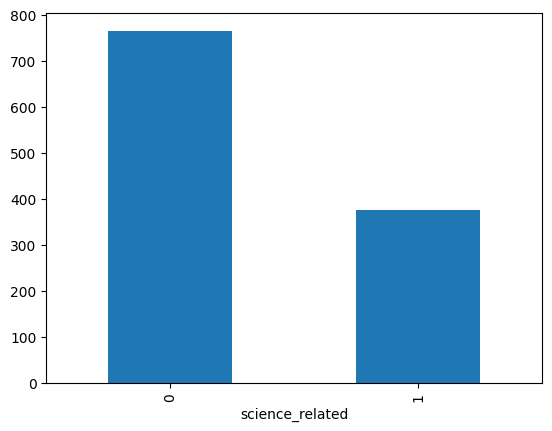

In [9]:
# Vérifier l’équilibrage
df["science_related"].value_counts().plot(kind="bar")
plt.show()


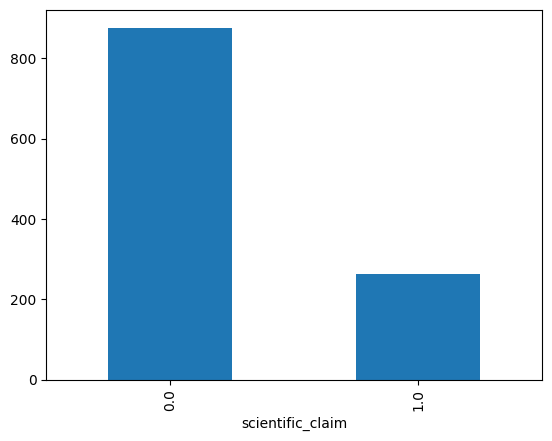

In [10]:
df["scientific_claim"].value_counts().plot(kind="bar")
plt.show()

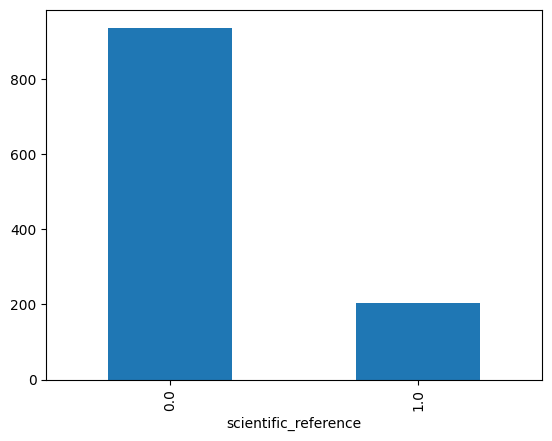

In [11]:
df["scientific_reference"].value_counts().plot(kind="bar")
plt.show()

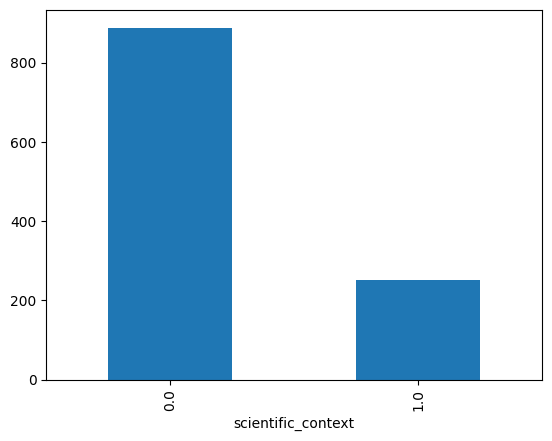

In [12]:
df["scientific_context"].value_counts().plot(kind="bar")
plt.show()

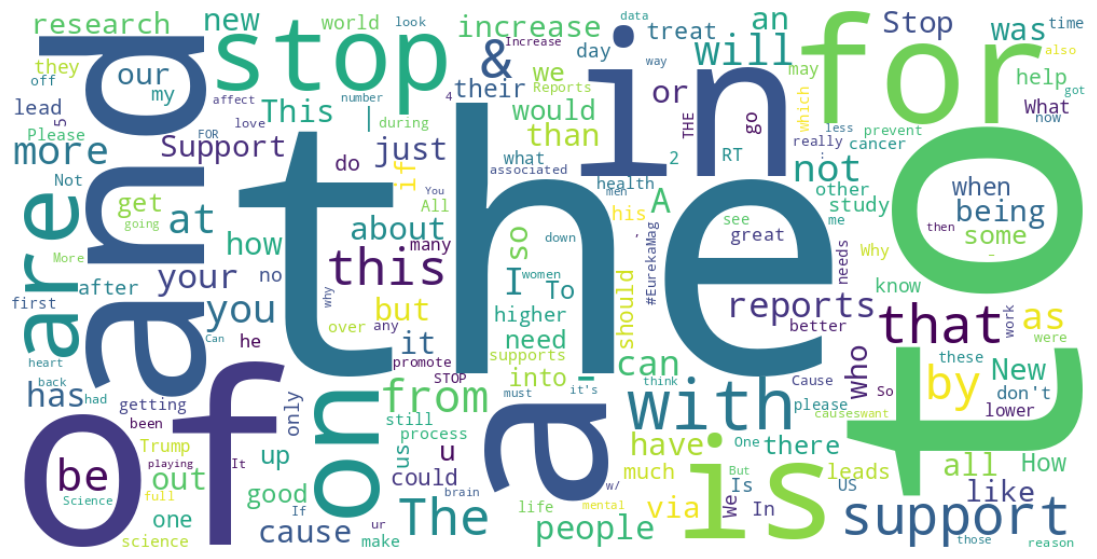

In [13]:
#Une première analyse des documents
#les Word Clouds
#sans nettoyage

# Garder seulement les textes non vides
texts = df["text"].dropna().astype(str)

# Concaténer tous les tweets en un seul gros texte
corpus = " ".join(texts)

# Découpage très simple
words = corpus.split()

# Comptage
word_counts = Counter(words)

# Word cloud
wc = WordCloud(width=1000, height=500, background_color="white")
wc.generate_from_frequencies(word_counts)

plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

In [14]:
# 2 - prétraitement

In [15]:
# test sent_tokenize
tweet_example = df["text"].dropna().iloc[0]
print(tweet_example)

phrases = sent_tokenize(tweet_example)
print(phrases)

Knees are a bit sore. i guess that's a sign that my recent treadmilling is working
['Knees are a bit sore.', "i guess that's a sign that my recent treadmilling is working"]


In [16]:
# test lower() et split()
tweet_example = df["text"].dropna().iloc[0]

print("Original :")
print(tweet_example)

print("\nMinuscules :")
print(tweet_example.lower())

print("\nAvec split :")
print(tweet_example.lower().split())

Original :
Knees are a bit sore. i guess that's a sign that my recent treadmilling is working

Minuscules :
knees are a bit sore. i guess that's a sign that my recent treadmilling is working

Avec split :
['knees', 'are', 'a', 'bit', 'sore.', 'i', 'guess', "that's", 'a', 'sign', 'that', 'my', 'recent', 'treadmilling', 'is', 'working']


In [17]:
# test word_tokenize(document)
tweet_example = df["text"].dropna().iloc[0]

tokens_split = tweet_example.lower().split()
tokens_nltk = word_tokenize(tweet_example)

print("split() :")
print(tokens_split)

print("\nword_tokenize() :")
print(tokens_nltk)

split() :
['knees', 'are', 'a', 'bit', 'sore.', 'i', 'guess', "that's", 'a', 'sign', 'that', 'my', 'recent', 'treadmilling', 'is', 'working']

word_tokenize() :
['Knees', 'are', 'a', 'bit', 'sore', '.', 'i', 'guess', 'that', "'s", 'a', 'sign', 'that', 'my', 'recent', 'treadmilling', 'is', 'working']


In [18]:
# test pos_tag
tweet_example = df["text"].dropna().iloc[0]
tokens = word_tokenize(tweet_example)
tags = nltk.pos_tag(tokens)

print(tags)

[('Knees', 'NNS'), ('are', 'VBP'), ('a', 'DT'), ('bit', 'NN'), ('sore', 'NN'), ('.', '.'), ('i', 'VB'), ('guess', 'NN'), ('that', 'WDT'), ("'s", 'VBZ'), ('a', 'DT'), ('sign', 'NN'), ('that', 'WDT'), ('my', 'PRP$'), ('recent', 'JJ'), ('treadmilling', 'NN'), ('is', 'VBZ'), ('working', 'VBG')]


In [19]:
# test filtrer par catégories
# par exemple garder seulement adjectifs et verbes

tweet_example = df["text"].dropna().iloc[0]
tokens = word_tokenize(tweet_example)
tags = nltk.pos_tag(tokens)

selected_tags = ["JJ", "VB", "VBD", "VBG"]
selected_words = [word for word, tag in tags if tag in selected_tags]

print("Tokens et tags :")
print(tags)

print("\nMots gardés :")
print(selected_words)

Tokens et tags :
[('Knees', 'NNS'), ('are', 'VBP'), ('a', 'DT'), ('bit', 'NN'), ('sore', 'NN'), ('.', '.'), ('i', 'VB'), ('guess', 'NN'), ('that', 'WDT'), ("'s", 'VBZ'), ('a', 'DT'), ('sign', 'NN'), ('that', 'WDT'), ('my', 'PRP$'), ('recent', 'JJ'), ('treadmilling', 'NN'), ('is', 'VBZ'), ('working', 'VBG')]

Mots gardés :
['i', 'recent', 'working']


In [20]:
# test tokens avec stopwords
stop_words = set(stopwords.words("english"))

tweet_example = df["text"].dropna().iloc[0]
tokens = word_tokenize(tweet_example.lower())

tokens_no_stop = [w for w in tokens if w.isalpha() and w not in stop_words]

print("Tokens avant :")
print(tokens)

print("\nTokens sans stopwords :")
print(tokens_no_stop)

Tokens avant :
['knees', 'are', 'a', 'bit', 'sore', '.', 'i', 'guess', 'that', "'s", 'a', 'sign', 'that', 'my', 'recent', 'treadmilling', 'is', 'working']

Tokens sans stopwords :
['knees', 'bit', 'sore', 'guess', 'sign', 'recent', 'treadmilling', 'working']


In [21]:
# test personnaliser les stopwords

custom_stopwords = {"rt", "amp", "http"}

final_stopwords = stop_words.union(custom_stopwords)

df["tokens_no_stop_custom"] = df["text"].fillna("").apply(
    lambda x: [w for w in word_tokenize(x.lower()) if w.isalpha() and w not in final_stopwords]
)

df[["text", "tokens_no_stop_custom"]].head()

,text,tokens_no_stop_custom
0,Knees are a bit sore. i guess that's a sign th...,"[knees, bit, sore, guess, sign, recent, treadm..."
1,McDonald's breakfast stop then the gym 🏀💪,"[mcdonald, breakfast, stop, gym]"
2,Can any Gynecologist with Cancer Experience ex...,"[gynecologist, cancer, experience, explain, da..."
3,Couch-lock highs lead to sleeping in the couch...,"[highs, lead, sleeping, couch, got, ta, stop, ..."
4,Does daily routine help prevent problems with ...,"[daily, routine, help, prevent, problems, bipo..."


In [22]:
# Initialisation du lemmatizer
lemmatizer = WordNetLemmatizer()

def clean_tweet(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)   # URLs
    text = re.sub(r"@\w+", " ", text)             # mentions
    text = re.sub(r"#", "", text)                 # garde le mot du hashtag
    text = re.sub(r"[^a-z\s]", " ", text)         # enlève ponctuation/chiffres
    text = re.sub(r"\s+", " ", text).strip()      # espaces propres
    return text

def tokenize_text(text):
    return word_tokenize(text)

def remove_stopwords(tokens):
    return [w for w in tokens if w not in stop_words]

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(w) for w in tokens]

def join_tokens(tokens):
    return " ".join(tokens)

In [23]:
# plusieurs représentations du même tweet

# V1 = nettoyage simple
df["text_v1"] = df["text"].apply(clean_tweet)

# V2 = nettoyage + tokenisation + suppression stopwords
df["tokens_v2"] = df["text_v1"].apply(tokenize_text)
df["tokens_v2"] = df["tokens_v2"].apply(remove_stopwords)
df["text_v2"] = df["tokens_v2"].apply(join_tokens)

# V3 = nettoyage + tokenisation + stopwords + lemmatisation
df["tokens_v3"] = df["text_v1"].apply(tokenize_text)
df["tokens_v3"] = df["tokens_v3"].apply(remove_stopwords)
df["tokens_v3"] = df["tokens_v3"].apply(lemmatize_tokens)
df["text_v3"] = df["tokens_v3"].apply(join_tokens)

In [24]:
# on teste une autre version avec stemming

from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

def stem_tokens(tokens):
    return [stemmer.stem(w) for w in tokens]

df["tokens_v4"] = df["text_v1"].apply(tokenize_text)
df["tokens_v4"] = df["tokens_v4"].apply(remove_stopwords)
df["tokens_v4"] = df["tokens_v4"].apply(stem_tokens)
df["text_v4"] = df["tokens_v4"].apply(join_tokens)

In [25]:
# comparaison
df[["text", "text_v1", "text_v2", "text_v3", "text_v4"]].head(5)

,text,text_v1,text_v2,text_v3,text_v4
0,Knees are a bit sore. i guess that's a sign th...,knees are a bit sore i guess that s a sign tha...,knees bit sore guess sign recent treadmilling ...,knee bit sore guess sign recent treadmilling w...,knee bit sore guess sign recent treadmil work
1,McDonald's breakfast stop then the gym 🏀💪,mcdonald s breakfast stop then the gym,mcdonald breakfast stop gym,mcdonald breakfast stop gym,mcdonald breakfast stop gym
2,Can any Gynecologist with Cancer Experience ex...,can any gynecologist with cancer experience ex...,gynecologist cancer experience explain dangers...,gynecologist cancer experience explain danger ...,gynecologist cancer experi explain danger tran...
3,Couch-lock highs lead to sleeping in the couch...,couch lock highs lead to sleeping in the couch...,couch lock highs lead sleeping couch got ta st...,couch lock high lead sleeping couch got ta sto...,couch lock high lead sleep couch got ta stop shit
4,Does daily routine help prevent problems with ...,does daily routine help prevent problems with ...,daily routine help prevent problems bipolar di...,daily routine help prevent problem bipolar dis...,daili routin help prevent problem bipolar disord


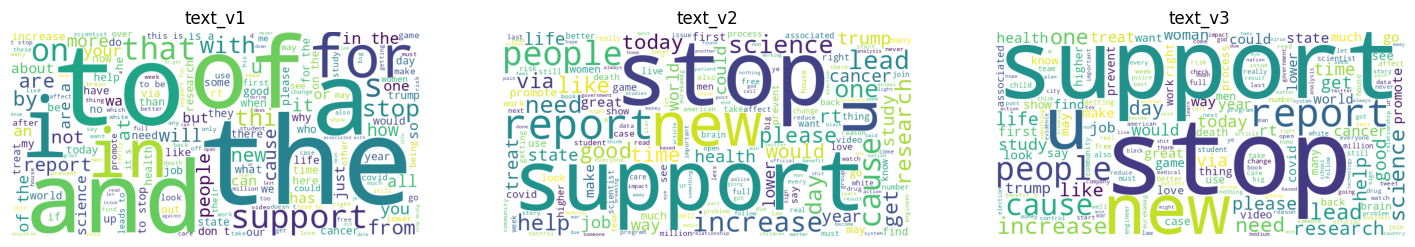

In [26]:
# word cloud pour comparaison
plt.figure(figsize=(18,6))

for i, col in enumerate(["text_v1", "text_v2", "text_v3"]):
    plt.subplot(1,3,i+1)

    corpus = " ".join(df[col].dropna().astype(str))
    wc = WordCloud(width=800, height=400, background_color="white", stopwords=[]).generate(corpus)

    plt.imshow(wc)
    plt.title(col)
    plt.axis("off")

plt.show()

In [27]:
# Exemple avec TF-IDF + Logistic Regression

y = df["science_related"]

versions = ["text_v1", "text_v2", "text_v3", "text_v4"]

for version in versions:
    X_train, X_test, y_train, y_test = train_test_split(
        df[version], y, test_size=0.2, random_state=42, stratify=y
    )

    vectorizer = TfidfVectorizer()
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)

    print(f"\n===== {version} =====")
    print("F1 macro :", f1_score(y_test, y_pred, average="macro"))
    print(classification_report(y_test, y_pred))



===== text_v1 =====
F1 macro : 0.5979781356529916
              precision    recall  f1-score   support

           0       0.72      0.99      0.83       153
           1       0.89      0.23      0.36        75

    accuracy                           0.74       228
   macro avg       0.81      0.61      0.60       228
weighted avg       0.78      0.74      0.68       228


===== text_v2 =====
F1 macro : 0.6247795932761255
              precision    recall  f1-score   support

           0       0.73      1.00      0.85       153
           1       1.00      0.25      0.40        75

    accuracy                           0.75       228
   macro avg       0.87      0.63      0.62       228
weighted avg       0.82      0.75      0.70       228


===== text_v3 =====
F1 macro : 0.6247795932761255
              precision    recall  f1-score   support

           0       0.73      1.00      0.85       153
           1       1.00      0.25      0.40        75

    accuracy                 

In [28]:

# Les colonnes science_related, scientific_claim, scientific_reference existent déjà dans le dataset

# CONTEXT = tweets science-related qui ne sont ni claim ni reference
df["scientific_context"] = ((df["science_related"] == 1) &
                            (df["scientific_claim"] == 0) &
                            (df["scientific_reference"] == 0)).astype(int)

# Première tache, SCI vs. NON-SCI
task1 = df[df["science_related"].isin([0, 1])].copy()
task1["label"] = task1["science_related"].astype(int)

# Deuxième tache, CLAIM, REF vs. {CONTEXT}
# On combine CLAIM et REF comme une seule classe
task2 = df[(df["science_related"] == 1)].copy()
# Label: 1 = CLAIM ou REF, 0 = CONTEXT
task2["label"] = ((task2["scientific_claim"] == 1) | (task2["scientific_reference"] == 1)).astype(int)

# Dernière tache, {CLAIM} vs. {REF} vs. {CONTEXT}
# On crée une seule colonne de label avec 3 classes
task3 = df[(df["science_related"] == 1)].copy()

def create_3class_label(row):
    if row["scientific_claim"] == 1:
        return 0
    elif row["scientific_reference"] == 1:
        return 1
    elif row["scientific_context"] == 1:
        return 2
    else:
        return -1

task3["label"] = task3.apply(create_3class_label, axis=1)

# On garde uniquement les labels valides
task3 = task3[task3["label"].isin([0, 1, 2])].copy()

print("DISTRIBUTION DES CLASSES")
print(f"Tâche 1 (SCI vs NON-SCI): {len(task1)} samples")
print(task1["label"].value_counts())

print(f"Tâche 2 (CLAIM/REF vs CONTEXT): {len(task2)} samples")
print(task2["label"].value_counts())

print(f"Tâche 3 (CLAIM vs REF vs CONTEXT): {len(task3)} samples")
print(task3["label"].value_counts())

DISTRIBUTION DES CLASSES
Tâche 1 (SCI vs NON-SCI): 1140 samples
label
0    765
1    375
Name: count, dtype: int64
Tâche 2 (CLAIM/REF vs CONTEXT): 375 samples
label
1    342
0     33
Name: count, dtype: int64
Tâche 3 (CLAIM vs REF vs CONTEXT): 375 samples
label
0    263
1     79
2     33
Name: count, dtype: int64


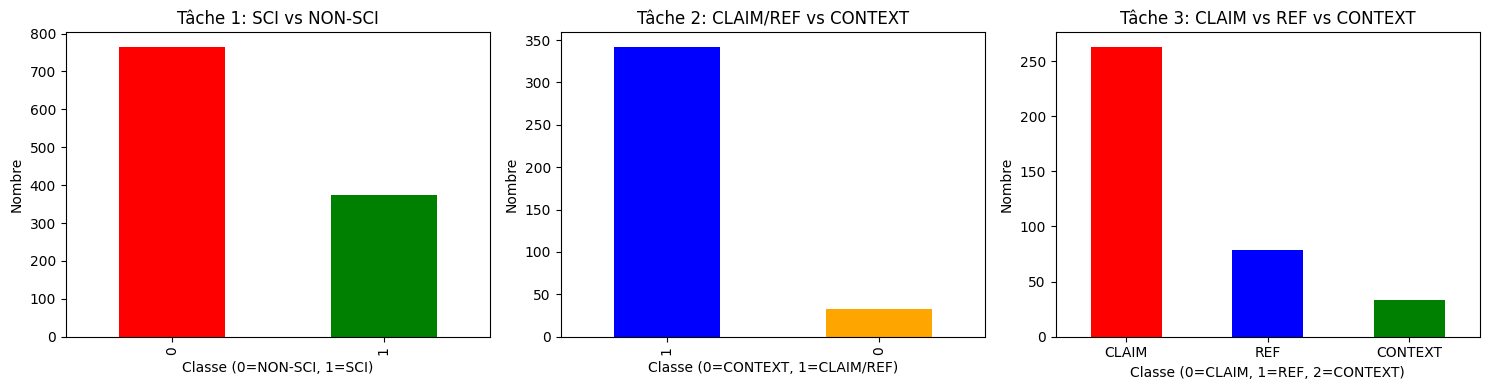


RATIO DE DÉSÉQUILIBRE
Tâche 1: 2.04:1 (max/min)
Tâche 2: 10.36:1 (max/min)
Tâche 3: 7.97:1 (max/min)


In [29]:
# Visualisation de la distribution des classes
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Tache 1
task1['label'].value_counts().plot(kind='bar', ax=axes[0], color=['red', 'green'])
axes[0].set_title('Tâche 1: SCI vs NON-SCI')
axes[0].set_xlabel('Classe (0=NON-SCI, 1=SCI)')
axes[0].set_ylabel('Nombre')

# Tache 2
task2['label'].value_counts().plot(kind='bar', ax=axes[1], color=['blue', 'orange'])
axes[1].set_title('Tâche 2: CLAIM/REF vs CONTEXT')
axes[1].set_xlabel('Classe (0=CONTEXT, 1=CLAIM/REF)')
axes[1].set_ylabel('Nombre')

# Tache 3
task3['label'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color=['red', 'blue', 'green'])
axes[2].set_title('Tâche 3: CLAIM vs REF vs CONTEXT')
axes[2].set_xlabel('Classe (0=CLAIM, 1=REF, 2=CONTEXT)')
axes[2].set_ylabel('Nombre')
axes[2].set_xticklabels(['CLAIM', 'REF', 'CONTEXT'], rotation=0)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

# Calcul du déséquilibre
print("\nRATIO DE DÉSÉQUILIBRE")
for name, task in [('Tâche 1', task1), ('Tâche 2', task2), ('Tâche 3', task3)]:
    counts = task['label'].value_counts()
    ratio = counts.max() / counts.min()
    print(f"{name}: {ratio:.2f}:1 (max/min)")

In [30]:
# Définition du pattern pour détecter les emojis dans le texte (aide de l'IA uniquement pour trouver les codes UTF des emojis)
emoji_pattern = re.compile(
    "[\U0001F600-\U0001F64F"
    "\U0001F300-\U0001F5FF"
    "\U0001F680-\U0001F6FF"
    "\U0001F700-\U0001F77F"
    "\U0001F780-\U0001F7FF"
    "\U0001F800-\U0001F8FF"
    "\U0001F900-\U0001F9FF"
    "\U0001FA00-\U0001FAFF"
    "\U00002700-\U000027BF"
    "\U00002600-\U000026FF"
    "]+",
    re.UNICODE
)

def extract_emojis_from_df(df):
    emojis = []

    # On parcourt chaque colonne de df
    for colonne in df.columns:
        # Puis chaque cellule de la colonne
        for valeur in df[colonne]:
            texte = str(valeur)

            # On cherche les emojis dans le texte
            emojis_trouves = emoji_pattern.findall(texte)

            # On les ajoute à la liste globale
            emojis.extend(emojis_trouves)

    return emojis


# Extraction
emojis = extract_emojis_from_df(df)

# Suppression des doublons en mettant dans un ensemble, puis tri
emojis_uniques = sorted(set(emojis))

# Affichage
print("\nEmojis uniques :", emojis_uniques)


Emojis uniques : ['☀', '☑', '☞', '☹', '♀', '♂', '♥', '♻', '⛟', '✋', '✌🏼', '✔', '✧', '❌', '❤', '➔', '➙', '➡', '🌊', '🌍', '🌞', '🍃💐🍁💐🍃', '🍷', '🍹', '🎥', '🏀💪', '🐦', '👀', '👁👁💙✨', '👇', '👉', '👊👊👊', '👌🏿👌🏻👌🏽👌🏼👌🏾', '👍', '👏', '👧💗💕', '💀💀💀💀', '💀😂', '💃🏻', '💔', '💕💕', '💖', '💙', '💥', '💪', '💯', '📲', '📸', '🔥', '🔥🤟💸👀', '🗽🌼🌱🌸🌺', '😂', '😂✋💃', '😂😂', '😂😂😂😂', '😃❤', '😄', '😅😅😅', '😈', '😉', '😊', '😍', '😎', '😐😐😐', '😜', '😜😜😜😜😜😜😜😜', '😡', '😢', '😢😢', '😧', '😬', '😭', '😭❤', '😭😭', '😷', '🙂', '🙄🙄', '🙆🏻', '🙋✋', '🙏🏼✈', '🤢🤢🤢', '🤣', '🤣🤣🤣🤣', '🤦🏽', '🤬🤬🤬🤬', '🦁💛', '🧡']


In [31]:
# FONCTIONS DE PRÉTRAITEMENT

# Initialisation des outils NLP
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Ajout de mots fréquents dans les tweets qu'on veut ignorer
tweet_stop_words = ['rt', 'amp', 'via', 'us', 'im', 'dont', 'cant',
                    'u', 'ur', 're', 've', 'll', 's']

for word in tweet_stop_words:
    stop_words.add(word)

# Dictionnaire pour transformer emojis en mots
emoji_dict = {
    '🏀': ' basketball ', '💪': ' strong ', '✋': ' stop ', '💃': ' dance ',
    '💖': ' love ', '💀': ' dead ', '😉': ' wink ', '😷': ' sick ',
    '😧': ' surprised ', '😐': ' neutral ', '☀': ' sunny ', '😎': ' cool ',
    '❤': ' love ', '😊': ' happy ', '😬': ' nervous ', '💃🏻': ' dancing ',
    '😜': ' playful ', '🤦🏽': ' facepalm ', '♀': ' female ', '🤟': ' love ',
    '💸': ' money ', '👀': ' eyes ', '😈': ' devil ', '💔': ' broken ',
    '💙': ' love ', '🌊': ' wave ', '♻': ' recycle ', '👊': ' fist ',
    '👇': ' down ', '🌍': ' earth ', '💕': ' love ', '😄': ' happy ',
    '♥': ' love ', '👧': ' girl ', '💗': ' love ', '🐦': ' bird ',
    '🤣': ' laughing ', '🙄': ' eye roll ', '☑': ' checked ', '☞': ' point ',
    '❌': ' wrong ', '🎥': ' movie ', '📲': ' phone ', '👏': ' clap ',
    '🌞': ' sun ', '😃': ' happy ', '🙆🏻': ' okay ', '♂': ' male ',
    '🙋': ' wave ', '🦁': ' lion ', '💛': ' love ', '🍹': ' drink ',
    '🍷': ' wine ', '🤬': ' angry ', '📸': ' camera ', '☹': ' sad ',
    '👌🏿': ' okay ', '👌🏻': ' okay ', '👌🏽': ' okay ', '👌🏼': ' okay ',
    '👌🏾': ' okay ', '🧡': ' love ', '🗽': ' statue ', '🌼': ' flower ',
    '🌱': ' plant ', '🌸': ' flower ', '🌺': ' flower ', '👁': ' eye ',
    '✨': ' sparkle ', '😍': ' love ', '💥': ' boom ', '✌🏼': ' victory ',
    '🙏🏼': ' pray ', '✈': ' plane ', '🙂': ' smile ', '🤢': ' sick ',
    '😅': ' nervous ', '✧': ' star ', '🍃': ' leaf ', '💐': ' bouquet ',
    '🍁': ' leaf ', '👉': ' point ', '➡': ' right ', '➔': ' right ',
    '💯': ' hundred ', '✔': ' check ', '➙': ' arrow ', '😢': ' sad ',
    '😡': ' angry '
}

# FONCTION DE NETTOYAGE
def clean_text(text):
    # on met tout en minuscule
    text = str(text).lower()

    # on enlève les liens
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # on enlève les @mentions
    text = re.sub(r'@\w+', '', text)

    # on enlève juste le # des hashtags
    text = re.sub(r'#', '', text)

    # on remplace les emojis par leur équivalent en texte
    for e in emoji_dict:
        text = text.replace(e, emoji_dict[e])

    # on garde que les lettres (le reste -> espace)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # on enlève les espaces en trop
    text = re.sub(r'\s+', ' ', text).strip()

    # on découpe en mots
    words = text.split()

    # on enlève les stopwords et mots qui font pas plus de 2 caractères, puis on lemmatise
    res = []
    for w in words:
        if w not in stop_words and len(w) > 2:
            res.append(lemmatizer.lemmatize(w))

    return " ".join(res)


# APPLICATION AUX DATASETS
task1['text_clean'] = task1['text'].apply(clean_text)
task2['text_clean'] = task2['text'].apply(clean_text)
task3['text_clean'] = task3['text'].apply(clean_text)


# STATISTIQUES
print("\nLONGUEUR DES TEXTES NETTOYÉS")

for nom, dataframe in [
    ('Tâche 1', task1),
    ('Tâche 2', task2),
    ('Tâche 3', task3)
]:
    moyenne_mots = dataframe['text_clean'].apply(
        lambda txt: len(txt.split())
    ).mean()

    print(f"{nom} : {moyenne_mots} mots en moyenne")


LONGUEUR DES TEXTES NETTOYÉS
Tâche 1 : 11.095614035087719 mots en moyenne
Tâche 2 : 11.568 mots en moyenne
Tâche 3 : 11.568 mots en moyenne


In [32]:
# FONCTIONS UTILITAIRES POUR LA MODÉLISATION
def prepare_task_data(task_df, test_size=0.2, random_state=42):
    X = task_df['text_clean']
    y = task_df['label']

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    # Vectorisation TF-IDF avec n-grammes
    vec = TfidfVectorizer(
        ngram_range=(1, 2),  # Unigrams + bigrams
        max_features=5000,
        min_df=2,
        max_df=0.95
    )
    X_train_v = vec.fit_transform(X_train)
    X_test_v = vec.transform(X_test)

    smote = SMOTE(random_state=random_state)
    X_train_v, y_train = smote.fit_resample(X_train_v, y_train)

    return X_train_v, X_test_v, y_train, y_test, vec


def evaluate_with_cv(X_train_v, y_train, classifier, cv=10):
    kfold = KFold(n_splits=cv, shuffle=True, random_state=42)
    scores = cross_val_score(classifier, X_train_v, y_train, cv=kfold, scoring='accuracy')
    return scores.mean(), scores.std()


def train_and_evaluate(X_train_v, X_test_v, y_train, y_test, classifier, name):
    clf = classifier.fit(X_train_v, y_train)
    y_pred = clf.predict(X_test_v)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')

    return {
        'name': name,
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'y_pred': y_pred,
        'model': clf
    }


def plot_confusion_matrix(y_test, y_pred, title, labels=None):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title(f'Matrice de Confusion - {title}')
    plt.xlabel('Prédit')
    plt.ylabel('Réel')
    plt.tight_layout()
    plt.savefig(f'cm_{title.replace(" ", "_")}.png', dpi=150)
    plt.show()

print("OK Fonctions de modélisation définies")

OK Fonctions de modélisation définies


In [33]:
#
# TÂCHE 1: SCI vs NON-SCI
#


print("TÂCHE 1: SCI vs NON-SCI")


# Préparation des données AVEC SMOTE
X_train_v, X_test_v, y_train, y_test, vec = prepare_task_data(task1)

print(f"Training set: {X_train_v.shape}")
print(f"Test set: {X_test_v.shape}")
print(f"Training labels distribution: {np.bincount(y_train)}")
# hmm la distribution est vraiment déséquilibrée...

# Définir les classifiers
classifiers = {
    'Naive Bayes': MultinomialNB(),
    'SVM': LinearSVC(max_iter=5000, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

# Évaluer chaque classifier
results_task1 = []

for name, clf in classifiers.items():
    # Validation croisée
    cv_mean, cv_std = evaluate_with_cv(X_train_v, y_train, clf)

    # Entraînement et test
    result = train_and_evaluate(X_train_v, X_test_v, y_train, y_test, clf, name)
    result['cv_mean'] = cv_mean
    result['cv_std'] = cv_std
    results_task1.append(result)

    print(f"\n{name}:")
    print(f"  CV Accuracy: {cv_mean:.4f} (+/- {cv_std:.4f})")
    print(f"  Test Accuracy: {result['accuracy']:.4f}")
    print(f"  F1-Score: {result['f1']:.4f}")

TÂCHE 1: SCI vs NON-SCI
Training set: (1224, 1593)
Test set: (228, 1593)
Training labels distribution: [612 612]

Naive Bayes:
  CV Accuracy: 0.8465 (+/- 0.0374)
  Test Accuracy: 0.7939
  F1-Score: 0.7966

SVM:
  CV Accuracy: 0.8555 (+/- 0.0342)
  Test Accuracy: 0.8026
  F1-Score: 0.8036

Logistic Regression:
  CV Accuracy: 0.8554 (+/- 0.0360)
  Test Accuracy: 0.8289
  F1-Score: 0.8308

Decision Tree:
  CV Accuracy: 0.7909 (+/- 0.0355)
  Test Accuracy: 0.7675
  F1-Score: 0.7634

KNN:
  CV Accuracy: 0.5016 (+/- 0.0244)
  Test Accuracy: 0.3465
  F1-Score: 0.1992

Random Forest:
  CV Accuracy: 0.8358 (+/- 0.0316)
  Test Accuracy: 0.7939
  F1-Score: 0.7971



RÉSULTATS COMPARATIFS - TÂCHE 1
         Classifier  CV Accuracy   CV Std  Test Accuracy  F1-Score  Precision   Recall
Logistic Regression     0.855424 0.036043       0.828947  0.830758   0.834194 0.828947
                SVM     0.855478 0.034221       0.802632  0.803589   0.804838 0.802632
      Random Forest     0.835819 0.031636       0.793860  0.797058   0.804013 0.793860
        Naive Bayes     0.846488 0.037362       0.793860  0.796570   0.801809 0.793860
      Decision Tree     0.790910 0.035514       0.767544  0.763446   0.761940 0.767544
                KNN     0.501606 0.024398       0.346491  0.199218   0.781191 0.346491

MEILLEUR MODÈLE TÂCHE 1: Logistic Regression
              precision    recall  f1-score   support

     NON-SCI       0.89      0.85      0.87       153
         SCI       0.72      0.79      0.75        75

    accuracy                           0.83       228
   macro avg       0.80      0.82      0.81       228
weighted avg       0.83      0.83      0

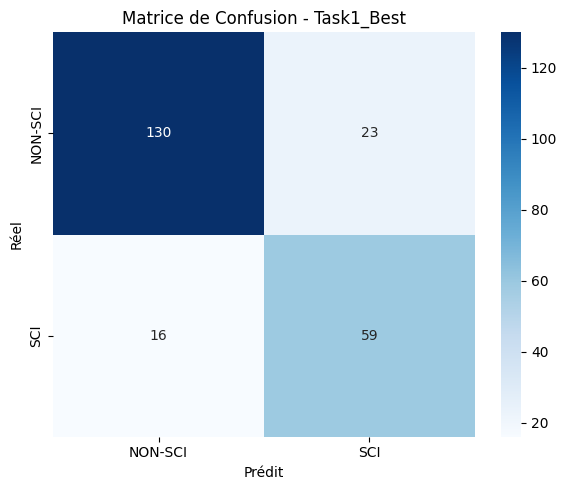

In [34]:
# Tableau comparatif Tâche 1
results_df1 = pd.DataFrame([{
    'Classifier': r['name'],
    'CV Accuracy': r['cv_mean'],
    'CV Std': r['cv_std'],
    'Test Accuracy': r['accuracy'],
    'F1-Score': r['f1'],
    'Precision': r['precision'],
    'Recall': r['recall']
} for r in results_task1])

print("\nRÉSULTATS COMPARATIFS - TÂCHE 1")
print(results_df1.sort_values('F1-Score', ascending=False).to_string(index=False))

# Matrice de confusion pour le meilleur modèle
best_task1 = max(results_task1, key=lambda x: x['f1'])
print(f"\nMEILLEUR MODÈLE TÂCHE 1: {best_task1['name']}")
print(classification_report(y_test, best_task1['y_pred'], target_names=['NON-SCI', 'SCI']))
plot_confusion_matrix(y_test, best_task1['y_pred'], 'Task1_Best', ['NON-SCI', 'SCI'])

In [35]:
#
# TÂCHE 2: CLAIM/REF vs CONTEXT
#


print("TÂCHE 2: CLAIM/REF vs CONTEXT")


# Préparation des données AVEC SMOTE
X_train_v, X_test_v, y_train, y_test, vec = prepare_task_data(task2)

print(f"Training set: {X_train_v.shape}")
print(f"Test set: {X_test_v.shape}")
print(f"Training labels distribution: {np.bincount(y_train)}")
# hmm la distribution est vraiment déséquilibrée...

# Évaluer chaque classifier
results_task2 = []

for name, clf in classifiers.items():
    # Validation croisée
    cv_mean, cv_std = evaluate_with_cv(X_train_v, y_train, clf)

    # Entraînement et test
    result = train_and_evaluate(X_train_v, X_test_v, y_train, y_test, clf, name)
    result['cv_mean'] = cv_mean
    result['cv_std'] = cv_std
    results_task2.append(result)

    print(f"\n{name}:")
    print(f"  CV Accuracy: {cv_mean:.4f} (+/- {cv_std:.4f})")
    print(f"  Test Accuracy: {result['accuracy']:.4f}")
    print(f"  F1-Score: {result['f1']:.4f}")

TÂCHE 2: CLAIM/REF vs CONTEXT
Training set: (548, 559)
Test set: (75, 559)
Training labels distribution: [274 274]

Naive Bayes:
  CV Accuracy: 0.9160 (+/- 0.0358)
  Test Accuracy: 0.8000
  F1-Score: 0.8320

SVM:
  CV Accuracy: 0.9380 (+/- 0.0120)
  Test Accuracy: 0.8667
  F1-Score: 0.8667

Logistic Regression:
  CV Accuracy: 0.9270 (+/- 0.0269)
  Test Accuracy: 0.8933
  F1-Score: 0.8933

Decision Tree:
  CV Accuracy: 0.9270 (+/- 0.0115)
  Test Accuracy: 0.9067
  F1-Score: 0.9094

KNN:
  CV Accuracy: 0.8487 (+/- 0.1131)
  Test Accuracy: 0.7333
  F1-Score: 0.7820

Random Forest:
  CV Accuracy: 0.9744 (+/- 0.0187)
  Test Accuracy: 0.9333
  F1-Score: 0.9160



RÉSULTATS COMPARATIFS - TÂCHE 2
         Classifier  CV Accuracy   CV Std  Test Accuracy  F1-Score  Precision   Recall
      Random Forest     0.974411 0.018689       0.933333  0.915997   0.937900 0.933333
      Decision Tree     0.927003 0.011512       0.906667  0.909432   0.912736 0.906667
Logistic Regression     0.927037 0.026904       0.893333  0.893333   0.893333 0.893333
                SVM     0.937980 0.012048       0.866667  0.866667   0.866667 0.866667
        Naive Bayes     0.915993 0.035815       0.800000  0.832044   0.883898 0.800000
                KNN     0.848687 0.113133       0.733333  0.781969   0.856642 0.733333

MEILLEUR MODÈLE TÂCHE 2: Random Forest
              precision    recall  f1-score   support

     CONTEXT       1.00      0.29      0.44         7
   CLAIM/REF       0.93      1.00      0.96        68

    accuracy                           0.93        75
   macro avg       0.97      0.64      0.70        75
weighted avg       0.94      0.93      0.92   

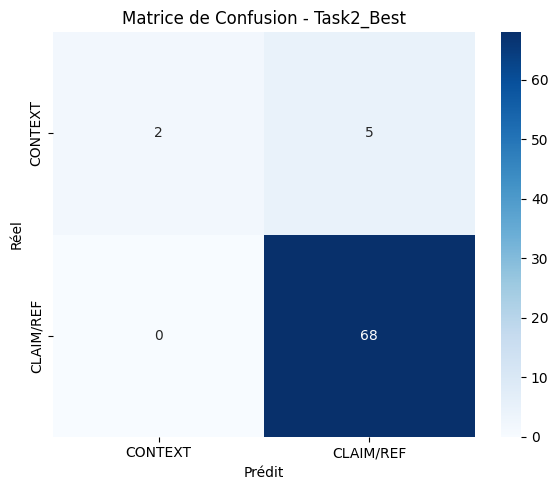

In [36]:
# Tableau comparatif Tâche 2
results_df2 = pd.DataFrame([{
    'Classifier': r['name'],
    'CV Accuracy': r['cv_mean'],
    'CV Std': r['cv_std'],
    'Test Accuracy': r['accuracy'],
    'F1-Score': r['f1'],
    'Precision': r['precision'],
    'Recall': r['recall']
} for r in results_task2])

print("\nRÉSULTATS COMPARATIFS - TÂCHE 2")
print(results_df2.sort_values('F1-Score', ascending=False).to_string(index=False))

# Matrice de confusion pour le meilleur modèle
best_task2 = max(results_task2, key=lambda x: x['f1'])
print(f"\nMEILLEUR MODÈLE TÂCHE 2: {best_task2['name']}")
print(classification_report(y_test, best_task2['y_pred'], target_names=['CONTEXT', 'CLAIM/REF']))
plot_confusion_matrix(y_test, best_task2['y_pred'], 'Task2_Best', ['CONTEXT', 'CLAIM/REF'])

In [37]:
#
# TÂCHE 3: CLAIM vs REF vs CONTEXT (3-classes)
#


print("TÂCHE 3: CLAIM vs REF vs CONTEXT")


# Préparation des données AVEC SMOTE
X_train_v, X_test_v, y_train, y_test, vec = prepare_task_data(task3)

print(f"Training set: {X_train_v.shape}")
print(f"Test set: {X_test_v.shape}")
print(f"Training labels distribution: {np.bincount(y_train)}")
# hmm la distribution est vraiment déséquilibrée...

# Évaluer chaque classifier
results_task3 = []

for name, clf in classifiers.items():
    # Validation croisée
    cv_mean, cv_std = evaluate_with_cv(X_train_v, y_train, clf)

    # Entraînement et test
    result = train_and_evaluate(X_train_v, X_test_v, y_train, y_test, clf, name)
    result['cv_mean'] = cv_mean
    result['cv_std'] = cv_std
    results_task3.append(result)

    print(f"\n{name}:")
    print(f"  CV Accuracy: {cv_mean:.4f} (+/- {cv_std:.4f})")
    print(f"  Test Accuracy: {result['accuracy']:.4f}")
    print(f"  F1-Score: {result['f1']:.4f}")

TÂCHE 3: CLAIM vs REF vs CONTEXT
Training set: (633, 554)
Test set: (75, 554)
Training labels distribution: [211 211 211]

Naive Bayes:
  CV Accuracy: 0.8137 (+/- 0.0499)
  Test Accuracy: 0.5867
  F1-Score: 0.6271

SVM:
  CV Accuracy: 0.9037 (+/- 0.0359)
  Test Accuracy: 0.6000
  F1-Score: 0.6297

Logistic Regression:
  CV Accuracy: 0.8880 (+/- 0.0494)
  Test Accuracy: 0.6133
  F1-Score: 0.6336

Decision Tree:
  CV Accuracy: 0.8169 (+/- 0.0488)
  Test Accuracy: 0.4933
  F1-Score: 0.5405

KNN:
  CV Accuracy: 0.6653 (+/- 0.0708)
  Test Accuracy: 0.2133
  F1-Score: 0.0927


/Users/zhangyaqi/Desktop/UM/M1/S2/Machine Learning - HAI817I/Projet_Common/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



Random Forest:
  CV Accuracy: 0.8295 (+/- 0.0226)
  Test Accuracy: 0.5467
  F1-Score: 0.5776



RÉSULTATS COMPARATIFS - TÂCHE 3
         Classifier  CV Accuracy   CV Std  Test Accuracy  F1-Score  Precision   Recall
Logistic Regression     0.888021 0.049449       0.613333  0.633636   0.663256 0.613333
                SVM     0.903745 0.035860       0.600000  0.629741   0.676931 0.600000
        Naive Bayes     0.813690 0.049883       0.586667  0.627130   0.694628 0.586667
      Random Forest     0.829464 0.022629       0.546667  0.577648   0.714626 0.546667
      Decision Tree     0.816915 0.048758       0.493333  0.540529   0.658939 0.493333
                KNN     0.665303 0.070830       0.213333  0.092651   0.090502 0.213333

MEILLEUR MODÈLE TÂCHE 3: Logistic Regression
              precision    recall  f1-score   support

       CLAIM       0.82      0.71      0.76        52
         REF       0.27      0.38      0.32        16
     CONTEXT       0.38      0.43      0.40         7

    accuracy                           0.61        75
   macro avg       0.49      0.51      0

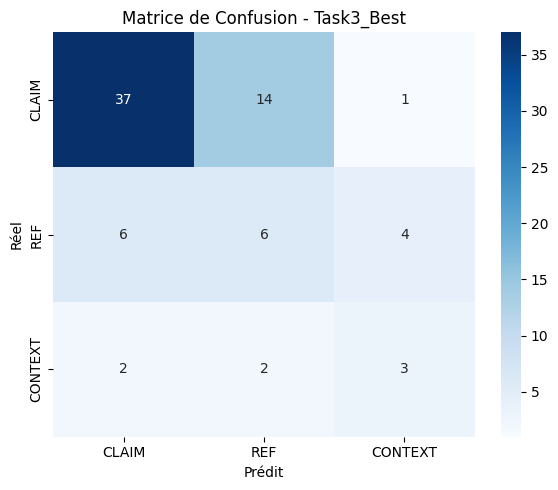

In [38]:
# Tableau comparatif Tâche 3
results_df3 = pd.DataFrame([{
    'Classifier': r['name'],
    'CV Accuracy': r['cv_mean'],
    'CV Std': r['cv_std'],
    'Test Accuracy': r['accuracy'],
    'F1-Score': r['f1'],
    'Precision': r['precision'],
    'Recall': r['recall']
} for r in results_task3])

print("\nRÉSULTATS COMPARATIFS - TÂCHE 3")
print(results_df3.sort_values('F1-Score', ascending=False).to_string(index=False))

# Matrice de confusion pour le meilleur modèle
best_task3 = max(results_task3, key=lambda x: x['f1'])
print(f"\nMEILLEUR MODÈLE TÂCHE 3: {best_task3['name']}")
print(classification_report(y_test, best_task3['y_pred'], target_names=['CLAIM', 'REF', 'CONTEXT']))
plot_confusion_matrix(y_test, best_task3['y_pred'], 'Task3_Best', ['CLAIM', 'REF', 'CONTEXT'])

In [39]:
# OPTIMISATION DES HYPERPARAMÈTRES AVEC GRIDSEARCHCV

# Grilles de paramètres pour les meilleurs classifiers
param_grids = {
    'Logistic Regression': {
        'C': [0.1, 1, 10],
        'max_iter': [1000]
    },
    'SVM': {
        'C': [0.1, 1, 10],
        'max_iter': [5000]
    },
    'Random Forest': {
        'n_estimators': [50, 100],
        'max_depth': [5, 10, None]
    }
}

# Optimisation pour chaque tâche

print("OPTIMISATION DES HYPERPARAMÈTRES")


best_params_results = {}

for task_name, task_data, results_list in [
    ('Tâche 1', task1, results_task1),
    ('Tâche 2', task2, results_task2),
    ('Tâche 3', task3, results_task3)
]:
    print(f"\n--- {task_name} ---")

    # Préparer les données
    X_train_v, X_test_v, y_train, y_test, vec = prepare_task_data(task_data)

    # Trouver le meilleur classifier de base
    best_clf_name = max(results_list, key=lambda x: x['f1'])['name']
    print(f"Meilleur classifier de base: {best_clf_name}")

    # Optimiser avec GridSearchCV
    if best_clf_name in param_grids:
        base_clf = classifiers[best_clf_name]

        grid_search = GridSearchCV(
            base_clf,
            param_grids[best_clf_name],
            cv=5,
            scoring='f1_weighted',
            n_jobs=-1
        )

        grid_search.fit(X_train_v, y_train)

        print(f"Meilleurs paramètres: {grid_search.best_params_}")
        print(f"Meilleur score CV: {grid_search.best_score_:.4f}")

        # Évaluer sur le test set
        y_pred = grid_search.best_estimator_.predict(X_test_v)
        test_f1 = f1_score(y_test, y_pred, average='weighted')
        test_acc = accuracy_score(y_test, y_pred)

        print(f"Test Accuracy: {test_acc:.4f}")
        print(f"Test F1-Score: {test_f1:.4f}")

        best_params_results[task_name] = {
            'classifier': best_clf_name,
            'params': grid_search.best_params_,
            'cv_score': grid_search.best_score_,
            'test_f1': test_f1,
            'test_acc': test_acc
        }

OPTIMISATION DES HYPERPARAMÈTRES

--- Tâche 1 ---
Meilleur classifier de base: Logistic Regression
Meilleurs paramètres: {'C': 1, 'max_iter': 1000}
Meilleur score CV: 0.8561
Test Accuracy: 0.8289
Test F1-Score: 0.8308

--- Tâche 2 ---
Meilleur classifier de base: Random Forest
Meilleurs paramètres: {'max_depth': None, 'n_estimators': 100}
Meilleur score CV: 0.9800
Test Accuracy: 0.9333
Test F1-Score: 0.9160

--- Tâche 3 ---
Meilleur classifier de base: Logistic Regression
Meilleurs paramètres: {'C': 10, 'max_iter': 1000}
Meilleur score CV: 0.9146
Test Accuracy: 0.6133
Test F1-Score: 0.6406


In [40]:
#
# SÉLECTION DE FEATURES AVEC CHI² (BONUS)
#


print("SÉLECTION DE FEATURES (BONUS)")


def get_top_features(task_df, task_name, top_k=20):
    # Préparer les données (sans SMOTE pour garder la distribution originale)
    X = task_df['text_clean']
    y = task_df['label']

    # Vectorisation
    vec = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
    X_v = vec.fit_transform(X)

    # Chi² test
    chi2_scores, p_values = chi2(X_v, y)

    # Créer un DataFrame des features
    feature_names = vec.get_feature_names_out()
    feature_scores = pd.DataFrame({
        'feature': feature_names,
        'chi2_score': chi2_scores
    }).sort_values('chi2_score', ascending=False)

    print(f"\nTop {top_k} features - {task_name}")
    print(feature_scores.head(top_k).to_string(index=False))

    return feature_scores.head(top_k)['feature'].tolist()

# Extraire les features pour chaque tâche
features_task1 = get_top_features(task1, 'Tâche 1: SCI vs NON-SCI')
features_task2 = get_top_features(task2, 'Tâche 2: CLAIM/REF vs CONTEXT')
features_task3 = get_top_features(task3, 'Tâche 3: CLAIM vs REF vs CONTEXT')

SÉLECTION DE FEATURES (BONUS)

Top 20 features - Tâche 1: SCI vs NON-SCI
       feature  chi2_score
          stop   12.395562
        health   10.630534
     eurekamag    9.145996
         study    7.347419
        cancer    6.750747
          risk    6.554734
       support    6.486770
         brain    6.143770
      research    5.258381
       climate    4.972596
     infection    4.897214
          cell    4.530505
         virus    4.316666
     scientist    4.302361
        stress    4.050706
         sleep    3.886488
     new study    3.881447
       poverty    3.852128
     treatment    3.805956
climate change    3.686247

Top 20 features - Tâche 2: CLAIM/REF vs CONTEXT
           feature  chi2_score
           science    7.718702
             april    7.715938
             grant    6.263142
brexit implication    6.214185
            brexit    6.214185
           support    5.646104
   cancer research    5.559733
             lupus    5.424633
             boole    5.351759
 

In [41]:
# TABLEAU COMPARATIF FINAL

print("TABLEAU COMPARATIF FINAL")


# Créer un tableau comparatif pour chaque tâche
def create_comparison_table(results_list, task_name):
    df = pd.DataFrame([{
        'Task': task_name,
        'Classifier': r['name'],
        'CV Accuracy': f"{r['cv_mean']:.4f} ± {r['cv_std']:.4f}",
        'Test Accuracy': f"{r['accuracy']:.4f}",
        'F1-Score': f"{r['f1']:.4f}"
    } for r in results_list])
    return df

comparison_df = pd.concat([
    create_comparison_table(results_task1, 'Task 1: SCI vs NON-SCI'),
    create_comparison_table(results_task2, 'Task 2: CLAIM/REF vs CONTEXT'),
    create_comparison_table(results_task3, 'Task 3: CLAIM vs REF vs CONTEXT')
])

print(comparison_df.to_string(index=False))

# Sauvegarder le tableau
comparison_df.to_csv('comparison_results.csv', index=False)
print("\nOK Résultats sauvegardés dans comparison_results.csv")

TABLEAU COMPARATIF FINAL
                           Task          Classifier     CV Accuracy Test Accuracy F1-Score
         Task 1: SCI vs NON-SCI         Naive Bayes 0.8465 ± 0.0374        0.7939   0.7966
         Task 1: SCI vs NON-SCI                 SVM 0.8555 ± 0.0342        0.8026   0.8036
         Task 1: SCI vs NON-SCI Logistic Regression 0.8554 ± 0.0360        0.8289   0.8308
         Task 1: SCI vs NON-SCI       Decision Tree 0.7909 ± 0.0355        0.7675   0.7634
         Task 1: SCI vs NON-SCI                 KNN 0.5016 ± 0.0244        0.3465   0.1992
         Task 1: SCI vs NON-SCI       Random Forest 0.8358 ± 0.0316        0.7939   0.7971
   Task 2: CLAIM/REF vs CONTEXT         Naive Bayes 0.9160 ± 0.0358        0.8000   0.8320
   Task 2: CLAIM/REF vs CONTEXT                 SVM 0.9380 ± 0.0120        0.8667   0.8667
   Task 2: CLAIM/REF vs CONTEXT Logistic Regression 0.9270 ± 0.0269        0.8933   0.8933
   Task 2: CLAIM/REF vs CONTEXT       Decision Tree 0.9270 ± 0.01

# Sources utiles
Le TP1 a fourni les bases de l'exploration et de la visualisation des données. Ensuite, on a utilisé le TP2 pour comprendre les outils de classification, validation croisée et optimisation.
Enfin, le projet gitlab a fourni le traitement spécifique aux données textuelles (TF-IDF, NLTK, prétraitement).
Pour trouver tout les emojis dans le tsv, une fonction python externe a été développée pour les récupérer.